# Drug Discovery Virtual Screening — Batch Prediction Pipeline

Third notebook of the project. It does **not** train anything: it loads the artefacts saved by
`02_machine_learning_models.ipynb` and scores a CSV of compound/protein pairs, writing the binary
activity call (`0` / `1`) back out to CSV.

| | |
|---|---|
| **Input** | any CSV with the 14 required descriptor columns |
| **Output** | `output/predictions.csv` — full result with probability, 0/1 call and predicted pKi |
| | `output/predictions_binary.csv` — minimal two-column file: identifier + `active` (0/1) |
| **Models used** | `models/best_classifier.joblib`, `models/best_regressor.joblib` |
| **Training** | none — this notebook is inference only |

## The leakage guard, restated and enforced here

`active` is exactly `binding_affinity >= 7.0`, so the two target columns are interchangeable. If
an input file happens to carry either of them — as the project's own dataset does — they must be
**removed before scoring**, otherwise a future edit could quietly feed the answer back into the
model and produce a perfect, meaningless result.

This notebook therefore:

1. strips `binding_affinity` and `active` from the incoming frame **before** any feature is built;
2. asserts that neither name appears in the model's feature contract;
3. **proves** the guard empirically — it scores the same rows twice, once with the target columns
   present and once with them deleted, and asserts the two results are bit-identical.

If a prediction ever changed when a target column was present, the pipeline would be leaking, and
the assertion in section 4 would stop the notebook.

---
## 1. Environment and artefacts

In [1]:
# Imports and paths
import importlib.util
import json
import shutil
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import seaborn as sns

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 220)

RANDOM_STATE = 42


def resolve_project_root() -> Path:
    here = Path.cwd().resolve()
    for candidate in [here, *here.parents]:
        if (candidate / "models" / "predict.py").exists():
            return candidate
        if (candidate / "input" / "drug_discovery_virtual_screening.csv").exists():
            return candidate
    return here


PROJECT_ROOT = resolve_project_root()
INPUT_DIR = PROJECT_ROOT / "input"
OUTPUT_DIR = PROJECT_ROOT / "output"
FIGURE_DIR = OUTPUT_DIR / "figures"
MODELS_DIR = PROJECT_ROOT / "models"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print("Project root :", PROJECT_ROOT)
print("Models folder:", MODELS_DIR)
print("Artefacts found:", sorted(p.name for p in MODELS_DIR.iterdir() if p.is_file()))

Project root : C:\Users\rafae.RAFAEL_NOTEBOOK\OneDrive\Documentos\Projetos_data_science_IA\kaggle\Projetos_kaggle\Drug Discovery Virtual Screening
Models folder: C:\Users\rafae.RAFAEL_NOTEBOOK\OneDrive\Documentos\Projetos_data_science_IA\kaggle\Projetos_kaggle\Drug Discovery Virtual Screening\models
Artefacts found: ['README.md', 'best_classifier.joblib', 'best_regressor.joblib', 'label_encoders.joblib', 'model_metadata.json', 'predict.py', 'requirements.txt']


In [2]:
# Visual identity (same palette as the other two notebooks)
CATEGORICAL = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100",
               "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
SURFACE = "#fcfcfb"
INK_PRIMARY, INK_SECONDARY, INK_MUTED = "#0b0b0b", "#52514e", "#8a8985"
GOOD, WARNING, CRITICAL = "#0ca30c", "#fab219", "#d03b3b"
SEQ_BLUE = LinearSegmentedColormap.from_list(
    "seq_blue", ["#cde2fb", "#9ec5f4", "#5598e7", "#2a78d6", "#256abf", "#184f95", "#0d366b"])

CLASS_COLORS = {0: CATEGORICAL[0], 1: CATEGORICAL[1]}
CLASS_LABELS = {0: "Predicted inactive (0)", 1: "Predicted active (1)"}

mpl.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "figure.dpi": 110, "savefig.dpi": 150, "font.size": 10.5,
    "axes.titlesize": 12.5, "axes.titleweight": "semibold", "axes.titlecolor": INK_PRIMARY,
    "axes.labelcolor": INK_SECONDARY, "axes.labelsize": 10.5,
    "axes.edgecolor": INK_MUTED, "axes.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#e6e5e1", "grid.linewidth": 0.7,
    "xtick.color": INK_SECONDARY, "ytick.color": INK_SECONDARY, "text.color": INK_PRIMARY,
    "legend.frameon": False, "legend.fontsize": 9.5,
    "lines.linewidth": 2.0, "lines.markersize": 5.5,
})

FIGURE_COUNTER = {"n": 0}


def legend_below(ax, handles=None, labels=None, ncol=3, y=-0.16, **kwargs):
    """Place the legend BELOW the plotting area."""
    if handles is None:
        handles, labels = ax.get_legend_handles_labels()
    if not handles:
        return None
    return ax.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, y),
                     ncol=ncol, frameon=False, borderaxespad=0.0, **kwargs)


def finalize(fig, caption, filename=None, reserve=0.0, pad=0.030):
    """Lay out the figure and write the English caption BELOW every artist, then save and show."""
    FIGURE_COUNTER["n"] += 1
    n = FIGURE_COUNTER["n"]
    if reserve:
        fig.tight_layout(rect=(0, reserve, 1, 1))
    else:
        fig.tight_layout()
    fig.canvas.draw()
    renderer = fig.canvas.get_renderer()
    to_figure = fig.transFigure.inverted()
    lows = []
    for ax in fig.axes:
        try:
            lows.append(to_figure.transform(ax.get_tightbbox(renderer).get_points())[0, 1])
        except Exception:
            pass
    for legend in fig.legends:
        try:
            lows.append(to_figure.transform(legend.get_window_extent(renderer).get_points())[0, 1])
        except Exception:
            pass
    baseline = min(lows) if lows else 0.0
    fig.text(0.5, baseline - pad, f"Figure {n} — {caption}", ha="center", va="top",
             fontsize=9.5, style="italic", color=INK_SECONDARY, wrap=True)
    fig.savefig(FIGURE_DIR / f"{filename or f'pred_{n:02d}'}.png",
                bbox_inches="tight", facecolor=SURFACE)
    plt.show()
    return n


print("Palette and figure helpers ready.")

Palette and figure helpers ready.


In [3]:
# Load the deployed model exactly as a production caller would
sys.dont_write_bytecode = True                 # keep the deployment folder clean
spec = importlib.util.spec_from_file_location("screening_predict", MODELS_DIR / "predict.py")
screening_predict = importlib.util.module_from_spec(spec)
spec.loader.exec_module(screening_predict)
shutil.rmtree(MODELS_DIR / "__pycache__", ignore_errors=True)

model = screening_predict.ScreeningModel(MODELS_DIR)
metadata = model.metadata

print(f"Classifier      : {metadata['classification']['best_model']}")
print(f"Regressor       : {metadata['regression']['best_model']}")
print(f"Decision cut-off: probability >= {model.threshold:.3f} -> active = 1")
print(f"Built on        : {metadata['created_at']}")
print(f"Features needed : {len(model.feature_order)} "
      f"(derived from {len(metadata['contract']['required_raw_columns'])} raw columns)")
print("\nHeld-out performance recorded at training time:")
print(f"  ROC-AUC {metadata['classification']['test_roc_auc']:.4f} | "
      f"average precision {metadata['classification']['test_average_precision']:.4f} | "
      f"F1 {metadata['classification']['test_f1_at_threshold']:.4f}")
print(f"  Regression RMSE {metadata['regression']['test_rmse']:.4f} pKi | "
      f"R2 {metadata['regression']['test_r2']:.4f}")

Classifier      : Logistic Regression
Regressor       : Linear Regression
Decision cut-off: probability >= 0.465 -> active = 1
Built on        : 2026-09-23T18:13:45
Features needed : 27 (derived from 14 raw columns)

Held-out performance recorded at training time:
  ROC-AUC 0.9578 | average precision 0.9265 | F1 0.8122
  Regression RMSE 0.7392 pKi | R2 0.6155


---
## 2. The input contract

The model needs exactly these raw columns. `compound_id` is optional and is only copied through to
the output so the shortlist can be read by a chemist.

In [4]:
# What the input CSV must contain
REQUIRED = metadata["contract"]["required_raw_columns"]
FORBIDDEN = ["binding_affinity", "active"]      # the two targets - see the leakage guard below

contract = pd.DataFrame({
    "column": REQUIRED,
    "role": ["categorical target identifier" if c == "protein_id" else "numeric descriptor"
             for c in REQUIRED],
    "required": True,
})
print(f"{len(REQUIRED)} required columns; `compound_id` optional; "
      f"{len(FORBIDDEN)} columns are actively rejected: {FORBIDDEN}")
contract

14 required columns; `compound_id` optional; 2 columns are actively rejected: ['binding_affinity', 'active']


,column,role,required
0,protein_id,categorical target identifier,True
1,molecular_weight,numeric descriptor,True
2,logp,numeric descriptor,True
3,h_bond_donors,numeric descriptor,True
4,h_bond_acceptors,numeric descriptor,True
5,rotatable_bonds,numeric descriptor,True
6,polar_surface_area,numeric descriptor,True
7,compound_clogp,numeric descriptor,True
8,protein_length,numeric descriptor,True
9,protein_pi,numeric descriptor,True


---
## 3. Loading the batch to score

`INPUT_CSV` is the only thing to change when scoring your own file. It defaults to the project's
own dataset, which conveniently carries the true labels so the predictions can be sanity-checked
at the end — but those label columns are stripped before any feature is computed.

In [5]:
# Point this at whatever file you want to score
INPUT_CSV = INPUT_DIR / "drug_discovery_virtual_screening.csv"

batch_raw = pd.read_csv(INPUT_CSV)
print(f"Loaded {len(batch_raw):,} rows x {batch_raw.shape[1]} columns from {INPUT_CSV.name}")
print(f"Distinct proteins in the batch : {batch_raw['protein_id'].nunique()}")
print(f"Missing values                 : {int(batch_raw.isna().sum().sum())} "
      f"(handled by the pipeline's imputer)")
batch_raw.head()

Loaded 2,000 rows x 17 columns from drug_discovery_virtual_screening.csv
Distinct proteins in the batch : 400
Missing values                 : 180 (handled by the pipeline's imputer)


,compound_id,protein_id,molecular_weight,logp,h_bond_donors,h_bond_acceptors,rotatable_bonds,polar_surface_area,compound_clogp,protein_length,protein_pi,hydrophobicity,binding_site_size,mw_ratio,logp_pi_interaction,binding_affinity,active
0,CID_00000,PID_361,499.671415,2.487233,1,7,4,113.350817,4.050696,678,6.019657,0.812534,12.512165,0.736978,14.972288,5.996665,0
1,CID_00001,PID_165,436.173570,3.283222,3,4,4,71.981132,3.704408,876,6.447408,0.651417,11.538420,0.497915,21.168271,6.445742,0
2,CID_00002,PID_168,514.768854,NaN,2,11,11,83.936307,1.869610,658,3.925837,0.633467,13.155702,0.782323,9.074061,5.689583,0
3,CID_00003,PID_226,602.302986,3.038058,0,5,5,79.868125,2.451909,312,7.597056,0.513038,12.071822,1.930458,23.080293,6.043438,0
4,CID_00004,PID_224,426.584663,0.659578,2,4,5,88.198676,1.771936,1418,4.249454,0.613571,15.850448,0.300835,2.802846,4.845055,0


In [6]:
# Validate the file against the contract BEFORE scoring anything
missing_columns = [c for c in REQUIRED if c not in batch_raw.columns]
present_targets = [c for c in FORBIDDEN if c in batch_raw.columns]
unseen_proteins = sorted(set(batch_raw["protein_id"].astype(str))
                         - set(model.label_encoders["protein_id"].classes_))

if missing_columns:
    raise ValueError(f"The input file is missing required columns: {missing_columns}")

print("Input validation")
print(f"  All {len(REQUIRED)} required columns present : yes")
print(f"  Target columns found in the file           : "
      f"{present_targets if present_targets else 'none'}")
print(f"  Proteins never seen during training        : {len(unseen_proteins)}"
      + (f" -> encoded as {metadata['contract']['unknown_category_code']}"
         if unseen_proteins else ""))
if unseen_proteins:
    print(f"    examples: {unseen_proteins[:5]}")

Input validation
  All 14 required columns present : yes
  Target columns found in the file           : ['binding_affinity', 'active']
  Proteins never seen during training        : 0


---
## 4. The leakage guard — enforced and then proved

This is the section the whole notebook exists to protect. Three checks run in order, and any one
of them failing stops execution.

In [7]:
# Strip the target columns before a single feature is computed
batch = batch_raw.drop(columns=[c for c in FORBIDDEN if c in batch_raw.columns])
truth = batch_raw[[c for c in FORBIDDEN if c in batch_raw.columns]].copy()  # kept ONLY for scoring later

print(f"Columns removed before scoring : {present_targets if present_targets else 'none'}")
print(f"Columns handed to the model    : {len(batch.columns)}")

# CHECK 1 - neither target may appear in the model's feature contract.
for forbidden in FORBIDDEN:
    assert forbidden not in model.feature_order, \
        f"LEAKAGE: `{forbidden}` is part of the model's feature list"
    assert forbidden not in REQUIRED, \
        f"LEAKAGE: `{forbidden}` is declared as a required input column"

# CHECK 2 - the frame actually handed over must not contain them either.
assert not set(FORBIDDEN) & set(batch.columns), "LEAKAGE: a target column survived the strip"

print("\nCheck 1 - targets absent from the model feature contract : PASSED")
print("Check 2 - targets absent from the frame being scored     : PASSED")

Columns removed before scoring : ['binding_affinity', 'active']
Columns handed to the model    : 15

Check 1 - targets absent from the model feature contract : PASSED
Check 2 - targets absent from the frame being scored     : PASSED


In [8]:
# Prove it: scoring WITH and WITHOUT the target columns must be identical
probe_rows = batch_raw.head(200)                       # these rows still carry both targets
with_targets = model.predict(probe_rows)
without_targets = model.predict(probe_rows.drop(columns=present_targets))

identical_probability = np.allclose(with_targets["activity_probability"],
                                    without_targets["activity_probability"], atol=0, rtol=0)
identical_affinity = np.allclose(with_targets["predicted_binding_affinity"],
                                 without_targets["predicted_binding_affinity"], atol=0, rtol=0)

print("Scoring 200 rows twice, once with the target columns present and once without them:")
print(f"  activity probabilities bit-identical : {identical_probability}")
print(f"  affinity predictions bit-identical   : {identical_affinity}")

# CHECK 3 - if a target column changed anything, the model is reading it. Stop.
assert identical_probability and identical_affinity, \
    "LEAKAGE: predictions changed when the target columns were present"
print("\nCheck 3 - predictions are invariant to the presence of the targets : PASSED")
print("\nThe pipeline provably does not read `binding_affinity` or `active`.")

Scoring 200 rows twice, once with the target columns present and once without them:
  activity probabilities bit-identical : True
  affinity predictions bit-identical   : True

Check 3 - predictions are invariant to the presence of the targets : PASSED

The pipeline provably does not read `binding_affinity` or `active`.


**Why check 3 is the one that matters.** Checks 1 and 2 are declarations: they confirm that the
code *says* the targets are excluded. Check 3 is a measurement: it confirms the model *behaves* as
if they are excluded, by scoring the same rows twice and comparing the numbers bit for bit. A
declaration can drift out of date when someone edits the feature list; a measurement cannot.

---
## 5. Scoring the batch

In [9]:
# Predict in chunks, so a file of any size works
CHUNK_SIZE = 5000

chunks = []
for start in range(0, len(batch), CHUNK_SIZE):
    piece = batch.iloc[start:start + CHUNK_SIZE]
    chunks.append(model.predict(piece))
    print(f"  scored rows {start:,} to {min(start + CHUNK_SIZE, len(batch)):,}")

predictions = pd.concat(chunks, axis=0)
predictions["predicted_active"] = predictions["predicted_active"].astype(int)

print(f"\n{len(predictions):,} compounds scored")
print(f"Predicted active (1)   : {int(predictions['predicted_active'].sum()):,} "
      f"({predictions['predicted_active'].mean() * 100:.1f}%)")
print(f"Predicted inactive (0) : {int((1 - predictions['predicted_active']).sum()):,} "
      f"({(1 - predictions['predicted_active'].mean()) * 100:.1f}%)")
predictions.head(10).round(4)

  scored rows 0 to 2,000

2,000 compounds scored
Predicted active (1)   : 567 (28.3%)
Predicted inactive (0) : 1,433 (71.7%)


,protein_id,compound_id,activity_probability,predicted_active,predicted_binding_affinity
0,PID_361,CID_00000,0.0148,0,5.9908
1,PID_165,CID_00001,0.0938,0,6.4174
2,PID_168,CID_00002,0.0035,0,5.5772
3,PID_226,CID_00003,0.0974,0,6.4248
4,PID_224,CID_00004,0.0006,0,5.0000
5,PID_201,CID_00005,0.0431,0,6.1501
6,PID_313,CID_00006,0.0283,0,6.2371
7,PID_477,CID_00007,0.0109,0,5.8471
8,PID_249,CID_00008,0.0864,0,6.3615
9,PID_164,CID_00009,0.3037,0,6.7011


In [10]:
# Add a screening priority so the output is directly actionable
predictions["rank"] = predictions["activity_probability"].rank(ascending=False, method="first").astype(int)
predictions["priority"] = pd.cut(
    predictions["activity_probability"],
    bins=[-0.001, 0.25, 0.50, 0.75, 1.001],
    labels=["4 - Deprioritise", "3 - Low", "2 - Medium", "1 - High"])

priority_summary = (predictions.groupby("priority", observed=False)
                    .agg(compounds=("priority", "size"),
                         mean_probability=("activity_probability", "mean"),
                         mean_predicted_affinity=("predicted_binding_affinity", "mean"),
                         called_active=("predicted_active", "sum"))
                    .sort_index())
priority_summary["share_pct"] = (priority_summary["compounds"] / len(predictions) * 100).round(1)
priority_summary.round(3)

,compounds,mean_probability,mean_predicted_affinity,called_active,share_pct
priority,,,,,
4 - Deprioritise,1228,0.054,5.966,0,61.4
3 - Low,224,0.357,6.850,19,11.2
2 - Medium,186,0.640,7.156,186,9.3
1 - High,362,0.925,7.885,362,18.1


---
## 6. Writing the CSV files

Two files are produced on purpose. The wide one is for a human reading the shortlist; the narrow
one is the machine-readable `0`/`1` file most downstream systems and competition submissions want.

In [11]:
# The full result
FULL_OUTPUT = OUTPUT_DIR / "predictions.csv"

full = predictions.copy()
full["activity_probability"] = full["activity_probability"].round(6)
full["predicted_binding_affinity"] = full["predicted_binding_affinity"].round(4)
full = full.sort_values("rank")

column_order = [c for c in ["compound_id", "protein_id", "rank", "priority",
                            "activity_probability", "predicted_active",
                            "predicted_binding_affinity"] if c in full.columns]
full = full[column_order]
full.to_csv(FULL_OUTPUT, index=False)

print(f"Wrote {len(full):,} rows to {FULL_OUTPUT}")
full.head(10)

Wrote 2,000 rows to C:\Users\rafae.RAFAEL_NOTEBOOK\OneDrive\Documentos\Projetos_data_science_IA\kaggle\Projetos_kaggle\Drug Discovery Virtual Screening\output\predictions.csv


,compound_id,protein_id,rank,priority,activity_probability,predicted_active,predicted_binding_affinity
1716,CID_01716,PID_147,1,1 - High,1.000000,1,10.9880
305,CID_00305,PID_329,2,1 - High,0.999998,1,10.2725
1952,CID_01952,PID_320,3,1 - High,0.999982,1,9.7998
1512,CID_01512,PID_231,4,1 - High,0.999976,1,9.7423
895,CID_00895,PID_413,5,1 - High,0.999966,1,9.4648
1455,CID_01455,PID_396,6,1 - High,0.999944,1,9.4396
35,CID_00035,PID_232,7,1 - High,0.999865,1,9.0982
218,CID_00218,PID_450,8,1 - High,0.999846,1,9.3192
1686,CID_01686,PID_236,9,1 - High,0.999788,1,9.1171
1982,CID_01982,PID_286,10,1 - High,0.999716,1,9.0115


In [12]:
# The minimal binary file: identifier + 0/1
BINARY_OUTPUT = OUTPUT_DIR / "predictions_binary.csv"

id_column = "compound_id" if "compound_id" in predictions.columns else None
binary = pd.DataFrame({
    "active": predictions["predicted_active"].astype(int).values,
}, index=predictions.index)
if id_column:
    binary.insert(0, id_column, predictions[id_column].values)
if "protein_id" in predictions.columns:
    binary.insert(1 if id_column else 0, "protein_id", predictions["protein_id"].values)

binary.to_csv(BINARY_OUTPUT, index=False)

print(f"Wrote {len(binary):,} rows to {BINARY_OUTPUT}")
print(f"Value counts of the `active` column: "
      f"{binary['active'].value_counts().sort_index().to_dict()}")
print(f"dtype of `active`: {binary['active'].dtype}  (integer 0/1, not True/False, not a float)")
binary.head(10)

Wrote 2,000 rows to C:\Users\rafae.RAFAEL_NOTEBOOK\OneDrive\Documentos\Projetos_data_science_IA\kaggle\Projetos_kaggle\Drug Discovery Virtual Screening\output\predictions_binary.csv
Value counts of the `active` column: {0: 1433, 1: 567}
dtype of `active`: int32  (integer 0/1, not True/False, not a float)


,compound_id,protein_id,active
0,CID_00000,PID_361,0
1,CID_00001,PID_165,0
2,CID_00002,PID_168,0
3,CID_00003,PID_226,0
4,CID_00004,PID_224,0
5,CID_00005,PID_201,0
6,CID_00006,PID_313,0
7,CID_00007,PID_477,0
8,CID_00008,PID_249,0
9,CID_00009,PID_164,0


In [13]:
# Read both files back from disk and verify them
reloaded_full = pd.read_csv(FULL_OUTPUT)
reloaded_binary = pd.read_csv(BINARY_OUTPUT)

checks = pd.DataFrame([
    ("Row count matches the input", len(reloaded_full) == len(batch_raw)),
    ("Binary file row count matches", len(reloaded_binary) == len(batch_raw)),
    ("`active` contains only 0 and 1", set(reloaded_binary["active"].unique()) <= {0, 1}),
    ("`active` is an integer column", pd.api.types.is_integer_dtype(reloaded_binary["active"])),
    ("No missing values in the output", int(reloaded_full.isna().sum().sum()) == 0),
    ("No target column leaked into the output",
     not set(FORBIDDEN) & set(reloaded_full.columns)),
    ("0/1 call agrees with the stored threshold",
     bool(((reloaded_full["activity_probability"] >= model.threshold).astype(int)
           == reloaded_full["predicted_active"]).all())),
], columns=["check", "passed"])

assert checks["passed"].all(), f"Output validation failed:\n{checks}"
print("All output checks passed.")
checks

All output checks passed.


,check,passed
0,Row count matches the input,True
1,Binary file row count matches,True
2,`active` contains only 0 and 1,True
3,`active` is an integer column,True
4,No missing values in the output,True
5,No target column leaked into the output,True
6,0/1 call agrees with the stored threshold,True


---
## 7. What the batch looks like

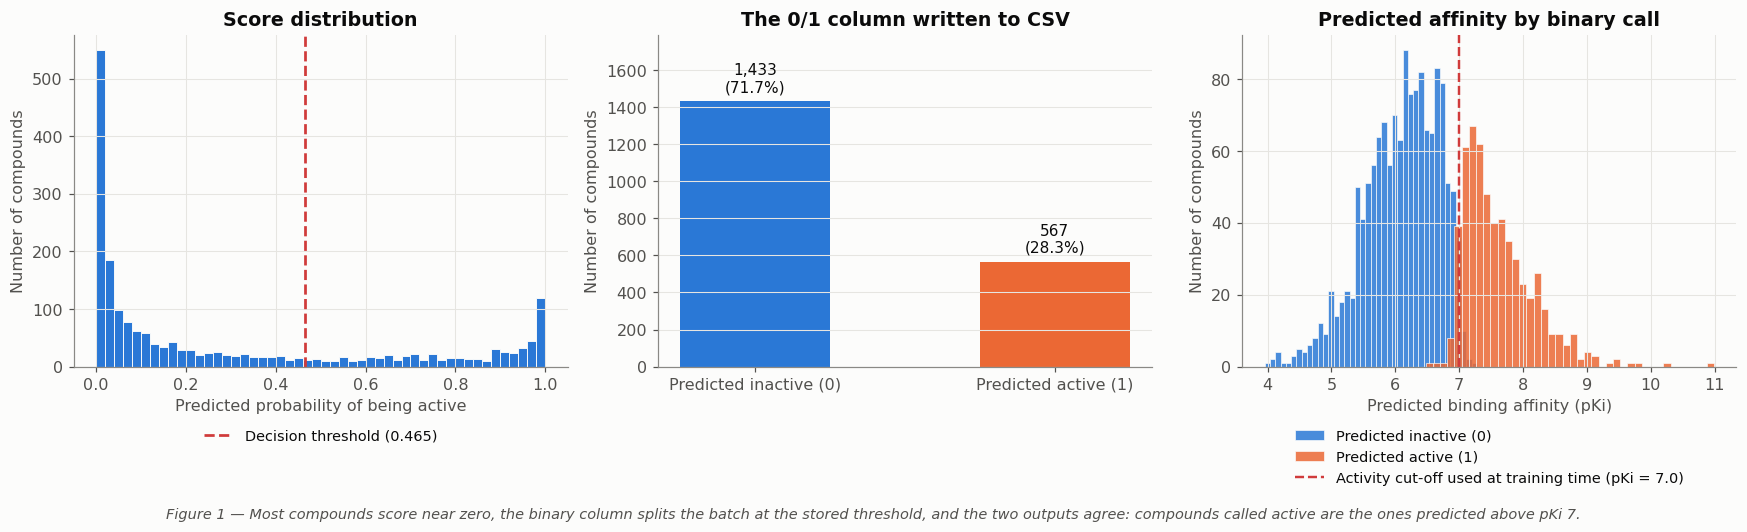

1

In [14]:
# Distribution of the scores and of the binary call
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))

ax = axes[0]
ax.hist(predictions["activity_probability"], bins=50, color=CATEGORICAL[0],
        edgecolor=SURFACE, linewidth=0.6)
ax.axvline(model.threshold, color=CRITICAL, linestyle="--", linewidth=1.8,
           label=f"Decision threshold ({model.threshold:.3f})")
ax.set_xlabel("Predicted probability of being active")
ax.set_ylabel("Number of compounds")
ax.set_title("Score distribution")
legend_below(ax, ncol=1, y=-0.17)

ax = axes[1]
counts = predictions["predicted_active"].value_counts().sort_index()
bars = ax.bar([CLASS_LABELS[k] for k in counts.index], counts.values,
              color=[CLASS_COLORS[k] for k in counts.index], width=0.5)
ax.bar_label(bars, labels=[f"{v:,}\n({v / len(predictions) * 100:.1f}%)" for v in counts.values],
             padding=4, fontsize=10, color=INK_PRIMARY)
ax.set_ylabel("Number of compounds")
ax.set_ylim(0, counts.max() * 1.25)
ax.set_title("The 0/1 column written to CSV")
ax.grid(axis="x", visible=False)

ax = axes[2]
for call in (0, 1):
    subset = predictions.loc[predictions["predicted_active"] == call,
                             "predicted_binding_affinity"]
    ax.hist(subset, bins=40, color=CLASS_COLORS[call], alpha=0.85,
            edgecolor=SURFACE, linewidth=0.5, label=CLASS_LABELS[call])
ax.axvline(7.0, color=CRITICAL, linestyle="--", linewidth=1.6,
           label="Activity cut-off used at training time (pKi = 7.0)")
ax.set_xlabel("Predicted binding affinity (pKi)")
ax.set_ylabel("Number of compounds")
ax.set_title("Predicted affinity by binary call")
legend_below(ax, ncol=1, y=-0.17)

finalize(fig, "Most compounds score near zero, the binary column splits the batch at the stored "
              "threshold, and the two outputs agree: compounds called active are the ones predicted "
              "above pKi 7.",
         "pred_01_score_distribution")

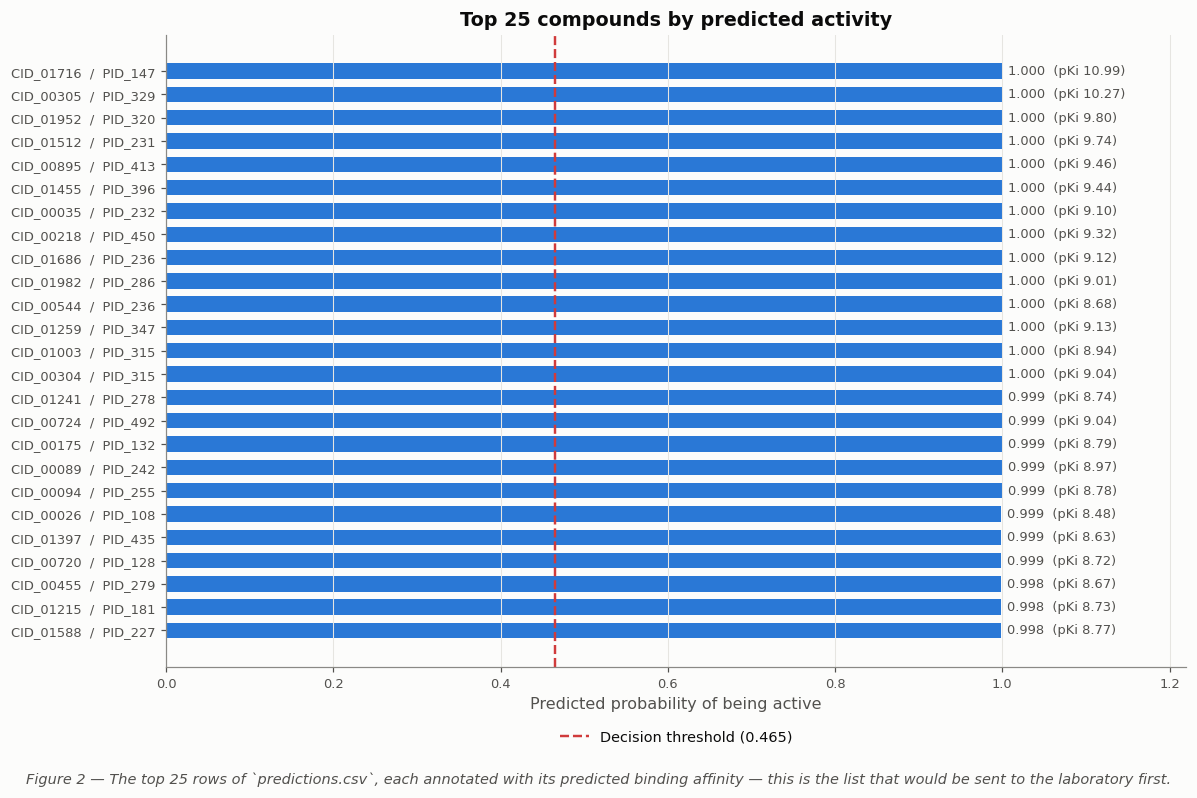

2

In [15]:
# The shortlist a chemistry team would actually receive
TOP_N = 25
shortlist = full.head(TOP_N)

fig, ax = plt.subplots(figsize=(11, 7))
ordered = shortlist.iloc[::-1]
labels = (ordered["compound_id"] + "  /  " + ordered["protein_id"]
          if "compound_id" in ordered.columns else ordered["protein_id"])
bars = ax.barh(labels, ordered["activity_probability"], height=0.66, color=CATEGORICAL[0])
ax.bar_label(bars, labels=[f"{p:.3f}  (pKi {a:.2f})" for p, a
                           in zip(ordered["activity_probability"],
                                  ordered["predicted_binding_affinity"])],
             padding=4, fontsize=8.5, color=INK_SECONDARY)
ax.axvline(model.threshold, color=CRITICAL, linestyle="--", linewidth=1.6,
           label=f"Decision threshold ({model.threshold:.3f})")
ax.set_xlim(0, 1.22)
ax.set_xlabel("Predicted probability of being active")
ax.set_title(f"Top {TOP_N} compounds by predicted activity")
ax.tick_params(labelsize=8.5)
ax.grid(axis="y", visible=False)
legend_below(ax, ncol=1, y=-0.09)

finalize(fig, f"The top {TOP_N} rows of `predictions.csv`, each annotated with its predicted binding "
              f"affinity — this is the list that would be sent to the laboratory first.",
         "pred_02_shortlist")

**One caveat about this particular shortlist.** The demonstration file is the project's own
dataset, so 80% of these rows were part of the model's training data and the model partly
remembers them. The ranking is therefore *flattering* here. That is fine for showing what the
output looks like, but it is why the performance numbers in the next section are computed on the
held-out rows only. On a genuinely new batch — the normal case — every row is unseen and no such
caveat applies.

---
## 8. Sanity check against the true labels

The demonstration file carries the real `active` and `binding_affinity` columns, which were
stripped before scoring. They can now be used to check the predictions — but **only the held-out
rows give an honest number**, because the model was trained on the other 80%.

The split below is recreated with the same seed, test size and stratification used in
`02_machine_learning_models.ipynb`, so the "test rows" here are exactly the rows the model never
saw.

In [16]:
# Recreate the original split and score the two halves separately
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, average_precision_score, matthews_corrcoef,
                             confusion_matrix, mean_absolute_error, mean_squared_error, r2_score)

HAS_LABELS = {"active", "binding_affinity"} <= set(truth.columns)
validation = None

if not HAS_LABELS:
    print("The input file carries no labels, so no sanity check is possible. "
          "This is the normal case when scoring genuinely new compounds.")
else:
    y_true = truth["active"].astype(int).to_numpy()
    y_affinity = truth["binding_affinity"].to_numpy()
    probability = predictions["activity_probability"].to_numpy()
    y_hat = predictions["predicted_active"].to_numpy()
    affinity_hat = predictions["predicted_binding_affinity"].to_numpy()

    train_idx, test_idx = train_test_split(
        np.arange(len(batch_raw)), test_size=0.20, random_state=RANDOM_STATE, stratify=y_true)

    rows = []
    for split_name, index in [("Training rows (model has seen these)", train_idx),
                              ("Held-out rows (never seen - the honest number)", test_idx),
                              ("Whole file (mixture - do not quote this)", np.arange(len(batch_raw)))]:
        rows.append({
            "split": split_name,
            "rows": len(index),
            "accuracy": accuracy_score(y_true[index], y_hat[index]),
            "precision": precision_score(y_true[index], y_hat[index], zero_division=0),
            "recall": recall_score(y_true[index], y_hat[index], zero_division=0),
            "f1": f1_score(y_true[index], y_hat[index], zero_division=0),
            "roc_auc": roc_auc_score(y_true[index], probability[index]),
            "average_precision": average_precision_score(y_true[index], probability[index]),
            "mcc": matthews_corrcoef(y_true[index], y_hat[index]),
            "rmse_affinity": float(np.sqrt(mean_squared_error(y_affinity[index],
                                                              affinity_hat[index]))),
            "r2_affinity": r2_score(y_affinity[index], affinity_hat[index]),
        })
    validation = pd.DataFrame(rows).set_index("split")

    print("The held-out row is the one to quote. It matches the value stored in "
          "`model_metadata.json` at training time:")
    print(f"  metadata ROC-AUC {metadata['classification']['test_roc_auc']:.4f} vs "
          f"recomputed {validation.loc['Held-out rows (never seen - the honest number)', 'roc_auc']:.4f}")

The held-out row is the one to quote. It matches the value stored in `model_metadata.json` at training time:
  metadata ROC-AUC 0.9578 vs recomputed 0.9578


In [17]:
validation.round(4) if validation is not None else "No labels in the input file - nothing to validate."

,rows,accuracy,precision,recall,f1,roc_auc,average_precision,mcc,rmse_affinity,r2_affinity
split,,,,,,,,,,
Training rows (model has seen these),1600,0.9062,0.8652,0.8189,0.8414,0.9481,0.9010,0.7756,0.7903,0.5625
Held-out rows (never seen - the honest number),400,0.8925,0.8692,0.7623,0.8122,0.9578,0.9265,0.7405,0.7392,0.6155
Whole file (mixture - do not quote this),2000,0.9035,0.8660,0.8076,0.8357,0.9498,0.9056,0.7685,0.7803,0.5731


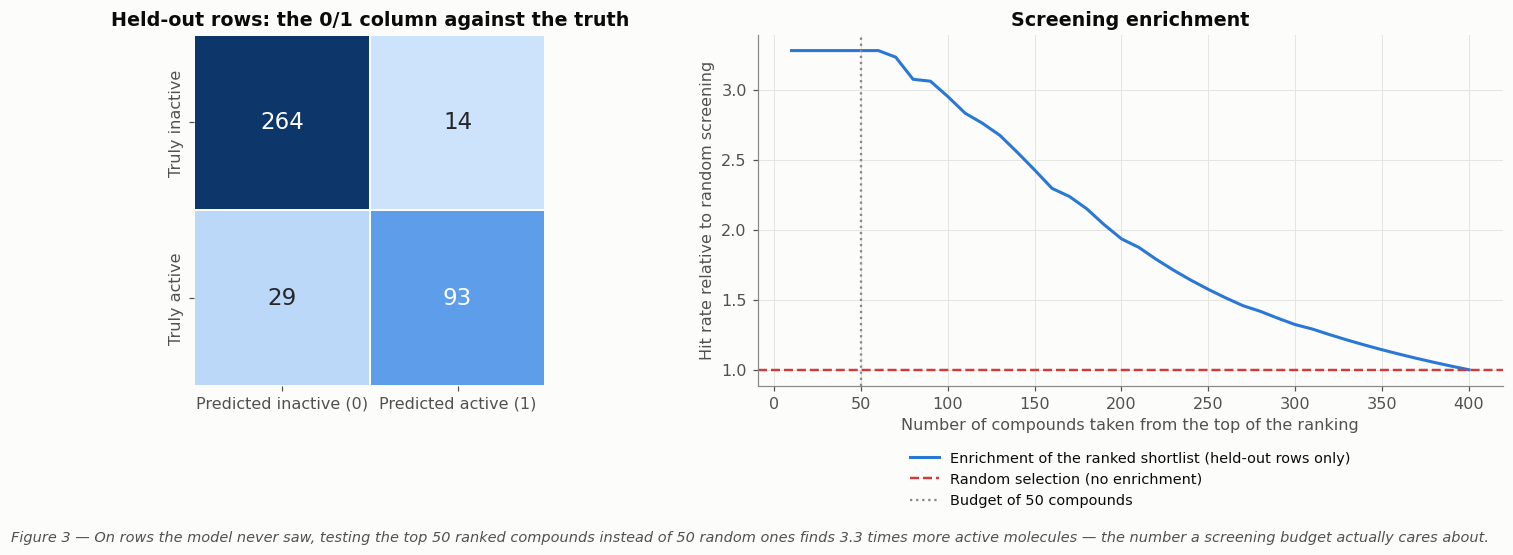

Held-out rows: 400 compounds, 30.5% truly active
True negatives 264 | False positives 14 | False negatives 29 | True positives 93
Precision of the top 50 ranked compounds : 100.0% -> 3.3x enrichment over random screening


In [18]:
# Confusion matrix and hit enrichment on the held-out rows
if HAS_LABELS:
    cm = confusion_matrix(y_true[test_idx], y_hat[test_idx])
    tn, fp, fn, tp = cm.ravel()

    # Everything below is computed on the HELD-OUT rows only. Ranking the whole file would put
    # memorised training compounds at the top of the shortlist and inflate the enrichment - the
    # same mistake as quoting training accuracy, just better disguised.
    held_out_truth = y_true[test_idx]
    held_out_score = probability[test_idx]
    base_rate = held_out_truth.mean()
    TOP_K = 50
    order = np.argsort(-held_out_score)
    precision_at_top = held_out_truth[order[:TOP_K]].mean()

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    ax = axes[0]
    sns.heatmap(cm, annot=True, fmt=",d", cmap=SEQ_BLUE, cbar=False, square=True,
                linewidths=1.2, linecolor=SURFACE, annot_kws={"size": 15}, ax=ax,
                xticklabels=["Predicted inactive (0)", "Predicted active (1)"],
                yticklabels=["Truly inactive", "Truly active"])
    ax.set_title("Held-out rows: the 0/1 column against the truth")
    ax.grid(visible=False)

    ax = axes[1]
    depths = np.arange(10, len(order) + 1, 10)
    enrichment = [held_out_truth[order[:d]].mean() / base_rate for d in depths]
    ax.plot(depths, enrichment, color=CATEGORICAL[0],
            label="Enrichment of the ranked shortlist (held-out rows only)")
    ax.axhline(1.0, color=CRITICAL, linestyle="--", linewidth=1.6,
               label="Random selection (no enrichment)")
    ax.axvline(TOP_K, color=INK_MUTED, linestyle=":", linewidth=1.5,
               label=f"Budget of {TOP_K} compounds")
    ax.set_xlabel("Number of compounds taken from the top of the ranking")
    ax.set_ylabel("Hit rate relative to random screening")
    ax.set_title("Screening enrichment")
    legend_below(ax, ncol=1, y=-0.17)

    finalize(fig, f"On rows the model never saw, testing the top {TOP_K} ranked compounds instead of "
                  f"{TOP_K} random ones finds {precision_at_top / base_rate:.1f} times more active "
                  f"molecules — the number a screening budget actually cares about.",
             "pred_03_validation")

    print(f"Held-out rows: {len(test_idx)} compounds, {base_rate * 100:.1f}% truly active")
    print(f"True negatives {tn} | False positives {fp} | False negatives {fn} | True positives {tp}")
    print(f"Precision of the top {TOP_K} ranked compounds : {precision_at_top * 100:.1f}% "
          f"-> {precision_at_top / base_rate:.1f}x enrichment over random screening")

**How to read the sanity check.** The training rows always look better than the held-out rows —
that is what memorisation looks like, and it is exactly why the middle row of the table is the only
one worth quoting. The third row, the whole file, is a blend of the two and is labelled as
something not to quote precisely because it is the number that is easiest to report by accident.
When you score genuinely new compounds there will be no label column at all and no check is
possible; the held-out number from training is the estimate you carry forward.

**The enrichment curve is the most useful business number in the whole project**, and it is
computed on held-out rows only for the same reason. It answers the question a screening budget
actually asks: *if we can afford to test N compounds, how many more hits do we find by testing the
model's top N instead of N at random?* Ranking the full file here would have quietly inflated that
answer, because memorised training compounds would crowd the top of the list.

---
## 9. Scoring genuinely new proteins

The realistic use case is a file of compounds screened against targets that were never in the
training set. The encoder maps an unknown `protein_id` to `-1` instead of raising, so the pipeline
degrades gracefully rather than failing.

In [19]:
# A small hand-built batch with proteins the model has never seen
new_batch = pd.DataFrame({
    "compound_id": ["NEW_0001", "NEW_0002", "NEW_0003", "NEW_0004", "NEW_0005"],
    "protein_id": ["PID_900", "PID_901", "PID_100", "PID_902", "PID_165"],
    "molecular_weight": [455.0, 612.4, 388.1, 501.7, 274.3],
    "logp": [5.8, 2.1, 4.4, np.nan, 3.0],            # one deliberately missing value
    "h_bond_donors": [1, 4, 2, 3, 1],
    "h_bond_acceptors": [6, 9, 4, 7, 3],
    "rotatable_bonds": [5, 11, 4, 8, 2],
    "polar_surface_area": [78.0, 132.5, 61.2, 95.4, 44.8],
    "compound_clogp": [5.1, 1.9, 4.0, 3.2, 2.8],
    "protein_length": [640, 1180, 705, 902, 876],
    "protein_pi": [8.4, 5.1, 6.9, 7.7, 6.4],
    "hydrophobicity": [0.72, 0.58, 0.65, 0.69, 0.65],
    "binding_site_size": [18.2, 12.4, 15.9, 16.8, 11.5],
    "mw_ratio": [455.0 / 640, 612.4 / 1180, 388.1 / 705, 501.7 / 902, 274.3 / 876],
    "logp_pi_interaction": [5.8 * 8.4, 2.1 * 5.1, 4.4 * 6.9, 4.9 * 7.7, 3.0 * 6.4],
})

new_predictions = model.predict(new_batch)
new_predictions["predicted_active"] = new_predictions["predicted_active"].astype(int)

NEW_OUTPUT = OUTPUT_DIR / "predictions_new_compounds.csv"
new_predictions.round(4).to_csv(NEW_OUTPUT, index=False)

encoded_ids = screening_predict.safe_label_transform(
    model.label_encoders["protein_id"], new_batch["protein_id"])
print("Protein encoding (-1 = never seen during training):")
for pid, code in zip(new_batch["protein_id"], encoded_ids):
    print(f"   {pid} -> {code}")
print(f"\nWrote {NEW_OUTPUT}")
new_predictions.round(4)

Protein encoding (-1 = never seen during training):
   PID_900 -> -1
   PID_901 -> -1
   PID_100 -> 0
   PID_902 -> -1
   PID_165 -> 65

Wrote C:\Users\rafae.RAFAEL_NOTEBOOK\OneDrive\Documentos\Projetos_data_science_IA\kaggle\Projetos_kaggle\Drug Discovery Virtual Screening\output\predictions_new_compounds.csv


,protein_id,compound_id,activity_probability,predicted_active,predicted_binding_affinity
0,PID_900,NEW_0001,0.9985,1,8.6168
1,PID_901,NEW_0002,0.0039,0,5.6700
2,PID_100,NEW_0003,0.6499,1,7.1122
3,PID_902,NEW_0004,0.9313,1,7.7926
4,PID_165,NEW_0005,0.0684,0,6.2046


**The row with the missing `logp` still scores.** Its gap is filled with the training median
inside the pipeline, exactly as it was during training, and the two proteins that never existed at
training time (`PID_900`, `PID_902`) are encoded as `-1` rather than raising an exception. Both
behaviours are what makes the artefact safe to put behind an API.

---
## 10. Summary

In [20]:
# What this notebook produced
produced = pd.DataFrame([
    ("output/predictions.csv", f"{len(full):,} rows",
     "Full result: rank, priority, probability, 0/1 call, predicted pKi"),
    ("output/predictions_binary.csv", f"{len(binary):,} rows",
     "Minimal file: identifier + `active` as integer 0/1"),
    ("output/predictions_new_compounds.csv", f"{len(new_predictions):,} rows",
     "Demonstration batch with unseen proteins and a missing value"),
    ("output/figures/pred_*.png", f"{FIGURE_COUNTER['n']} figures",
     "Score distribution, shortlist and validation"),
], columns=["file", "size", "content"])
produced

,file,size,content
0,output/predictions.csv,"2,000 rows","Full result: rank, priority, probability, 0/1 ..."
1,output/predictions_binary.csv,"2,000 rows",Minimal file: identifier + `active` as integer...
2,output/predictions_new_compounds.csv,5 rows,Demonstration batch with unseen proteins and a...
3,output/figures/pred_*.png,3 figures,"Score distribution, shortlist and validation"


### How to score your own file

1. Put a CSV anywhere on disk with the columns listed in section 2 (`compound_id` optional).
2. Change `INPUT_CSV` in section 3.1 to point at it.
3. Run the notebook top to bottom. `output/predictions_binary.csv` holds the `0`/`1` column.

Or skip the notebook entirely and use the command-line tool that ships with the models:

```bash
python models/predict.py my_compounds.csv my_predictions.csv
```

### The three rules this pipeline enforces

1. **`binding_affinity` and `active` never reach the model.** They are stripped on arrival, their
   absence from the feature contract is asserted, and section 4.2 proves empirically that the
   predictions do not change when they are present.
2. **Only held-out rows may be quoted as performance.** The table in section 8.1 separates the
   rows the model was trained on from the rows it has never seen, and labels the mixture as
   something not to quote.
3. **Unknown inputs degrade, they do not crash.** Missing descriptors are imputed with the
   training medians and unseen proteins are encoded as `-1`, so a production batch never fails on
   a value the training set happened not to contain.